In [1]:
# # Remove any existing cloned repo
# !rm -rf CrossCurrencyPrediction

# # Clone the repo
# !git clone https://github.com/mericdemirors/CrossCurrencyPrediction

# # Change directory to repo
# %cd CrossCurrencyPrediction/train_scripts

In [1]:
import argparse
from train import train_with_args
from evaluate import create_evaluation_graphs
from profit_inference import profit_inference, compare_profits
from trading_agents import get_trading_agent_values

args_dict = dict(
    model_name="", # name of the model to use
    input_window=28, # = number of time-series data in the input
    output_window=8, # = number of time-series data in the output
    dropout=0, # dropout p for the models
    num_layers=4, # number of layers in the LSTM/GRU/Transformer models
    hidden_dim=64, # dimension size for the LSTM/GRU/Transformer models
    num_heads=4, # number of heads for the Multiheadattention/Transformer
    teacher_forcing_ratio=1, # teacher forcing start ratio (what percentage of the training samples will be predicted utilizing the real data for later values in the output_window)
    teacher_forcing_ratio_decrease=0.05, # decrease in the teacher forcing ratio after each epoch
    
    input_coins=["BTC", "ETH", "BNB", "XRP"],
    input_features=["open", "close", "low", "high"],
    output_coins=["BTC"],
    output_features=["open", "close", "low", "high"],
    dataset_name="IntervalLogReturnTransformCoinDataset", # name of the dataset to use
    # csv path to load for training dataset
    train_csv_path="/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_train.csv",
    # csv path to load for validation dataset
    val_csv_path="/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_val.csv",
    profit_inference_csv_path="/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_val.csv",
    bank_start=1000,
    augmentation_p=0, # probability of a sample being augmented (also the probability of each augmentation being applied to that sample)
    augmentation_noise_std=0.04, # std for the gaussian noise augmentation
    augmentation_constant_c=0.05, # min max limit for the constant to be added to all samples
    augmentation_scale_s=0.05, # min max limit for the scale to be multiplied with all samples
    transform_name="QuantileTransformer", # sklearn.preprocessing QuantileTransformer or PowerTransformer to use
    output_distribution="normal", # sklearn.preprocessing QuantileTransformer distribution type
    n_quantiles=500, # sklearn.preprocessing QuantileTransformer number of quantiles
    merge_count=2, # how many intervals to merge for the MergedIntervalsLogReturnTransformCoinDataset dataset
    price_loss_with_real=True, # what to base the predictions for the price_loss calculation at the LogReturnTransformPriceLossCoinDataset dataset
    price_loss_weight=0.002, # how to weight the price_loss calculation at the LogReturnTransformPriceLossCoinDataset dataset

    plot_weight_grad=0, # whether to plot weight and gradient plots at each epoch
    
    loss_name="MAE", # name of the loss to use
    additional_loss_fn_names=[],#["low_high_loss", "variance_reward"], # any additional loss/regularization to use
    additional_loss_weights=[],#[0,0], # and their coefficients
    l1_loss_weight=0, # weight for the l1 regularization
    l2_loss_weight=0, # weight for the l2 regularization
    
    batch_size=256, # batch size
    epochs=1, # number of epochs
    epoch_plot_step=-1, # whether to plot mid-epoch inference plots, if so: plots the inference plots after each 'epoch_plot_step'th batch pass
    
    optimizer_name="Adam", # name of the optimizer to use
    lr=0.001, # learning rate
    lr_patience=10, # patience for learning rate scheduler, how many epochs to wait before dropping the learning rate
    lr_decrease=0.95, # multiplicative decrease for the learning rate scheduler, what to multiply with to drop the learning rate
    early_stop_patience=10, # early stop after no improvement in validation score
)

1


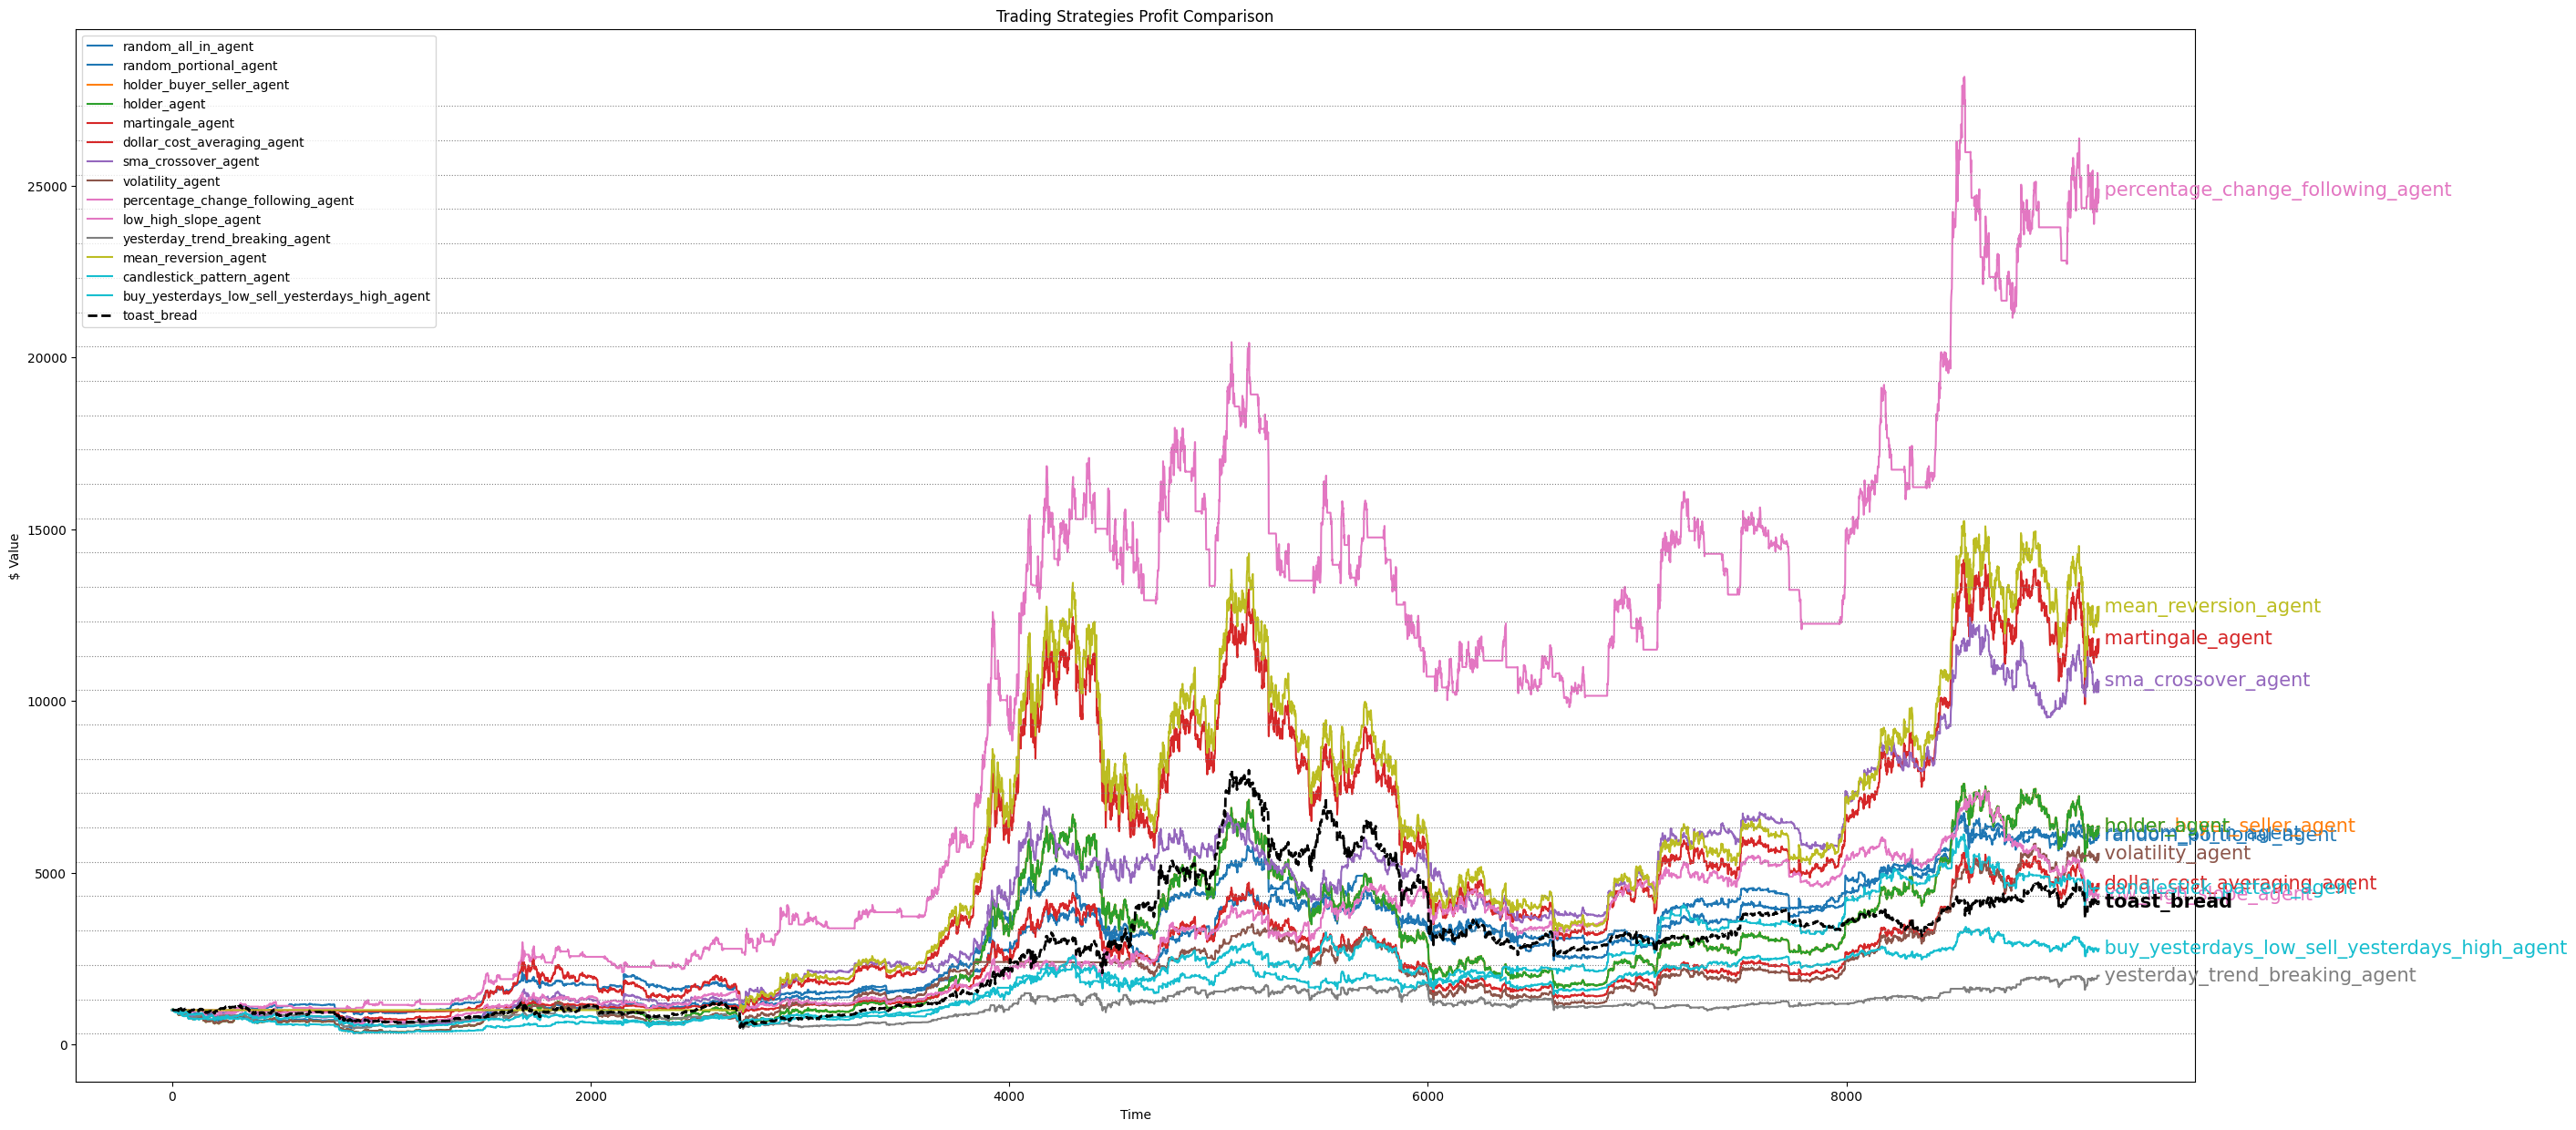

8


toast bread:  19%|█▉        | 1788/9179 [00:55<3:52:00,  1.88s/it]    

: 

In [2]:
train_session_dir = "train_sessions_zipped_second_phase/EncoderDecoderGRU_20250902_184342"
for er in [1,8,24,32]:
    print(er)
    toast_bread_values = profit_inference(train_session_dir, "/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_train.csv", bank_start=args_dict["bank_start"], error_margin=er)
    regular_agent_values = get_trading_agent_values("/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_train.csv", args_dict["output_coins"][0], args_dict["bank_start"])
    compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

In [ ]:
train_session_dir = "train_sessions_zipped_second_phase/EncoderDecoderGRU_20250902_191341"
for er in [1,8,24,32]:
    print(er)
    toast_bread_values = profit_inference(train_session_dir, "/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_train.csv", bank_start=args_dict["bank_start"], error_margin=er)
    regular_agent_values = get_trading_agent_values("/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_train.csv", args_dict["output_coins"][0], args_dict["bank_start"])
    compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

In [ ]:
train_session_dir = "train_sessions_zipped_second_phase/EncoderDecoderLSTM_20250902_185612"
for er in [1,8,24,32]:
    print(er)
    toast_bread_values = profit_inference(train_session_dir, "/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_train.csv", bank_start=args_dict["bank_start"], error_margin=er)
    regular_agent_values = get_trading_agent_values("/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_train.csv", args_dict["output_coins"][0], args_dict["bank_start"])
    compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

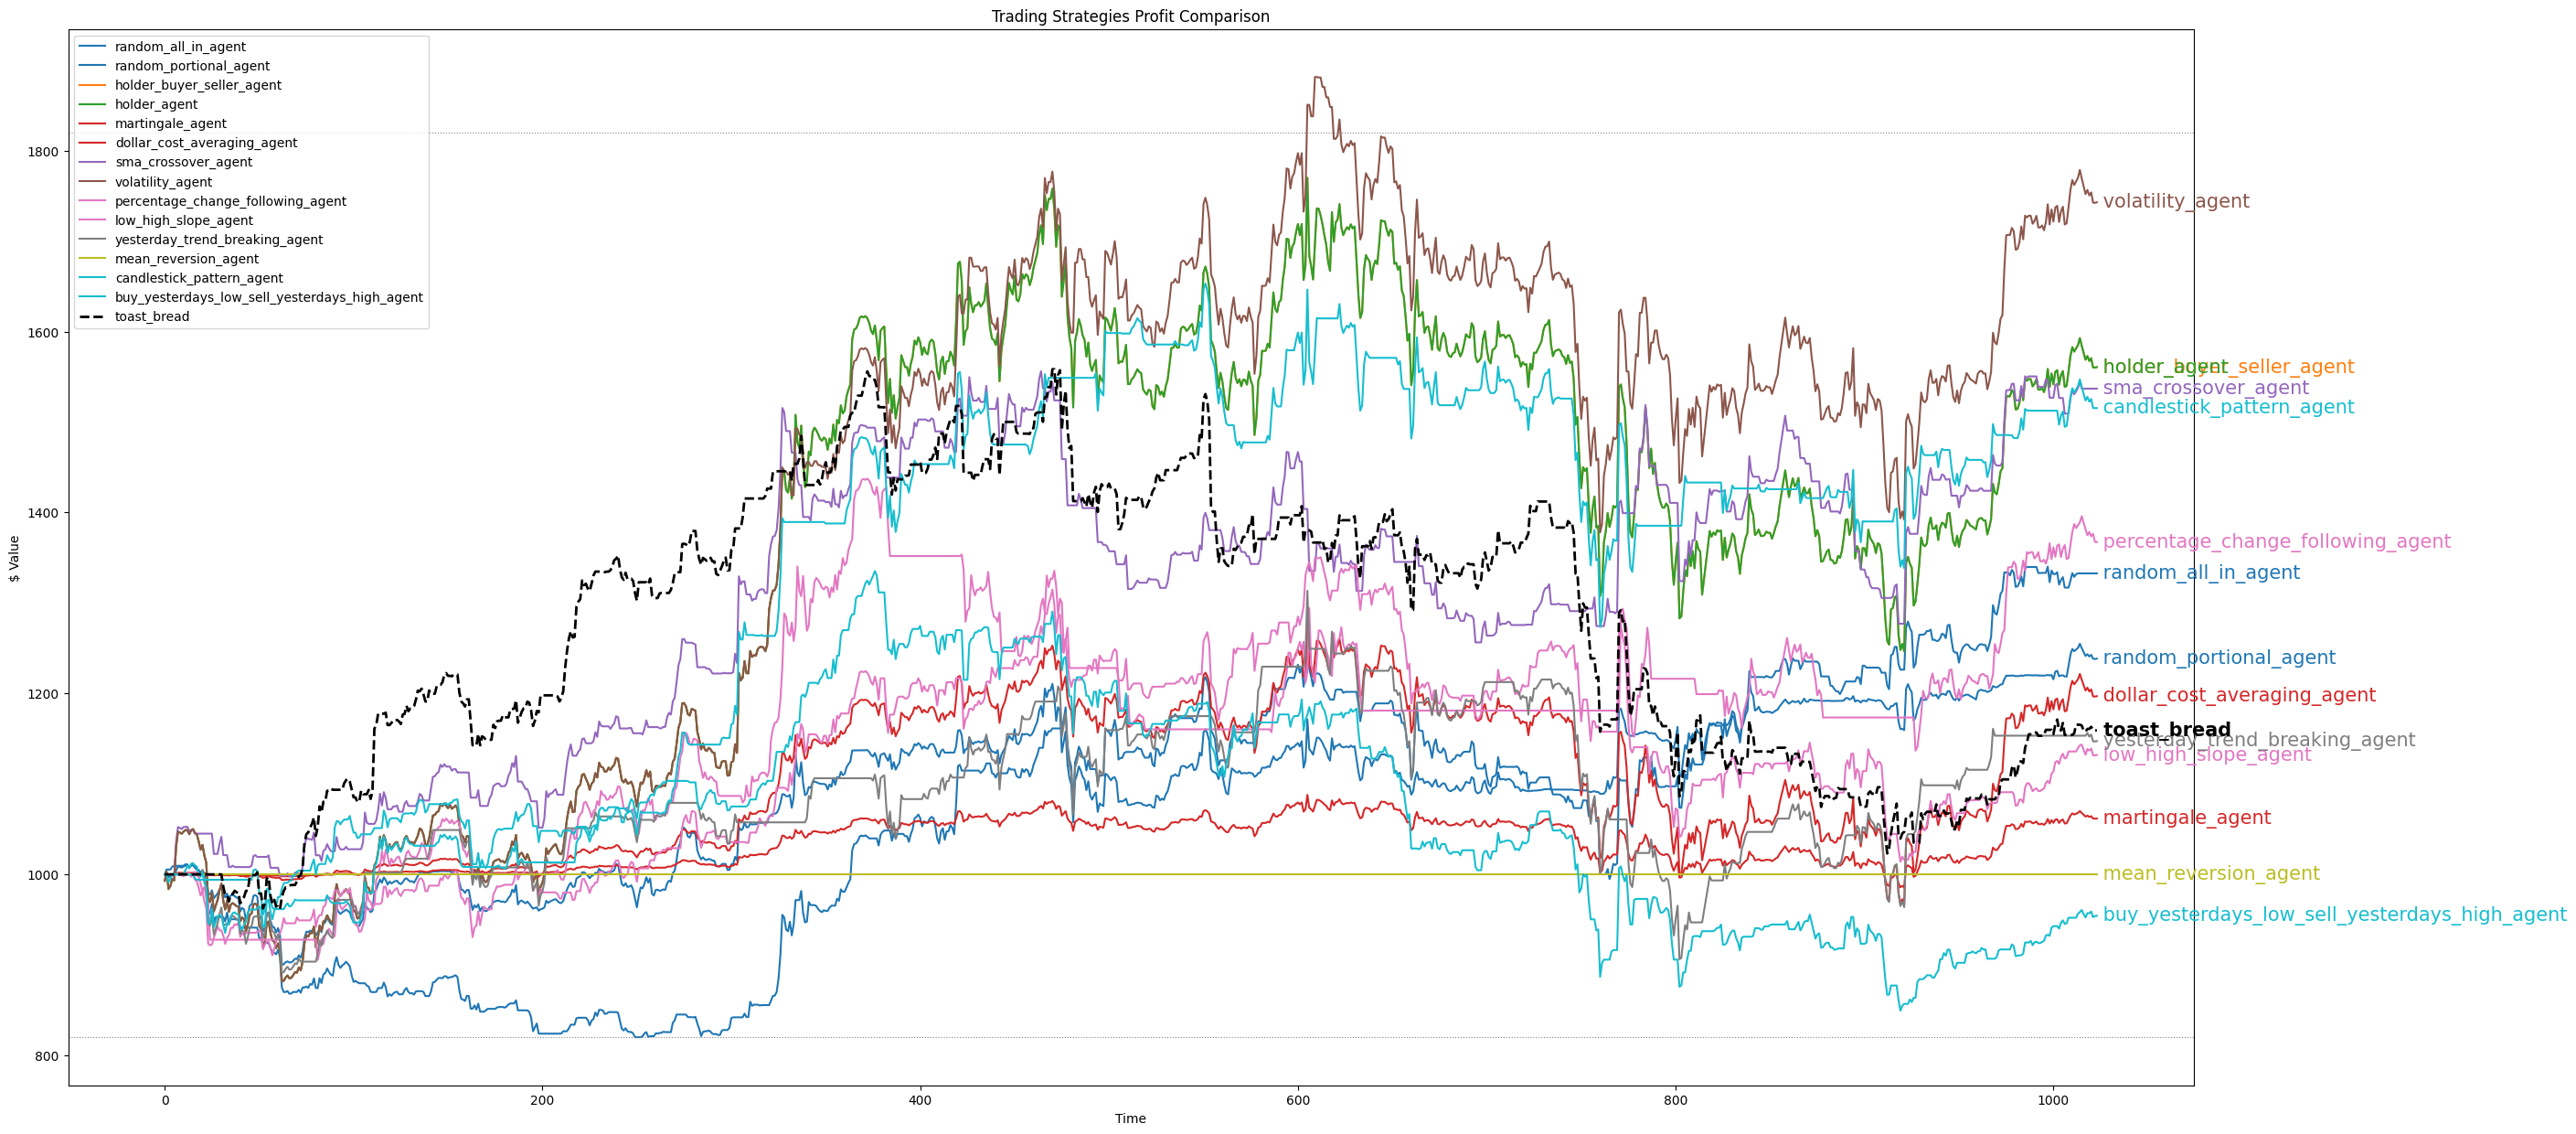

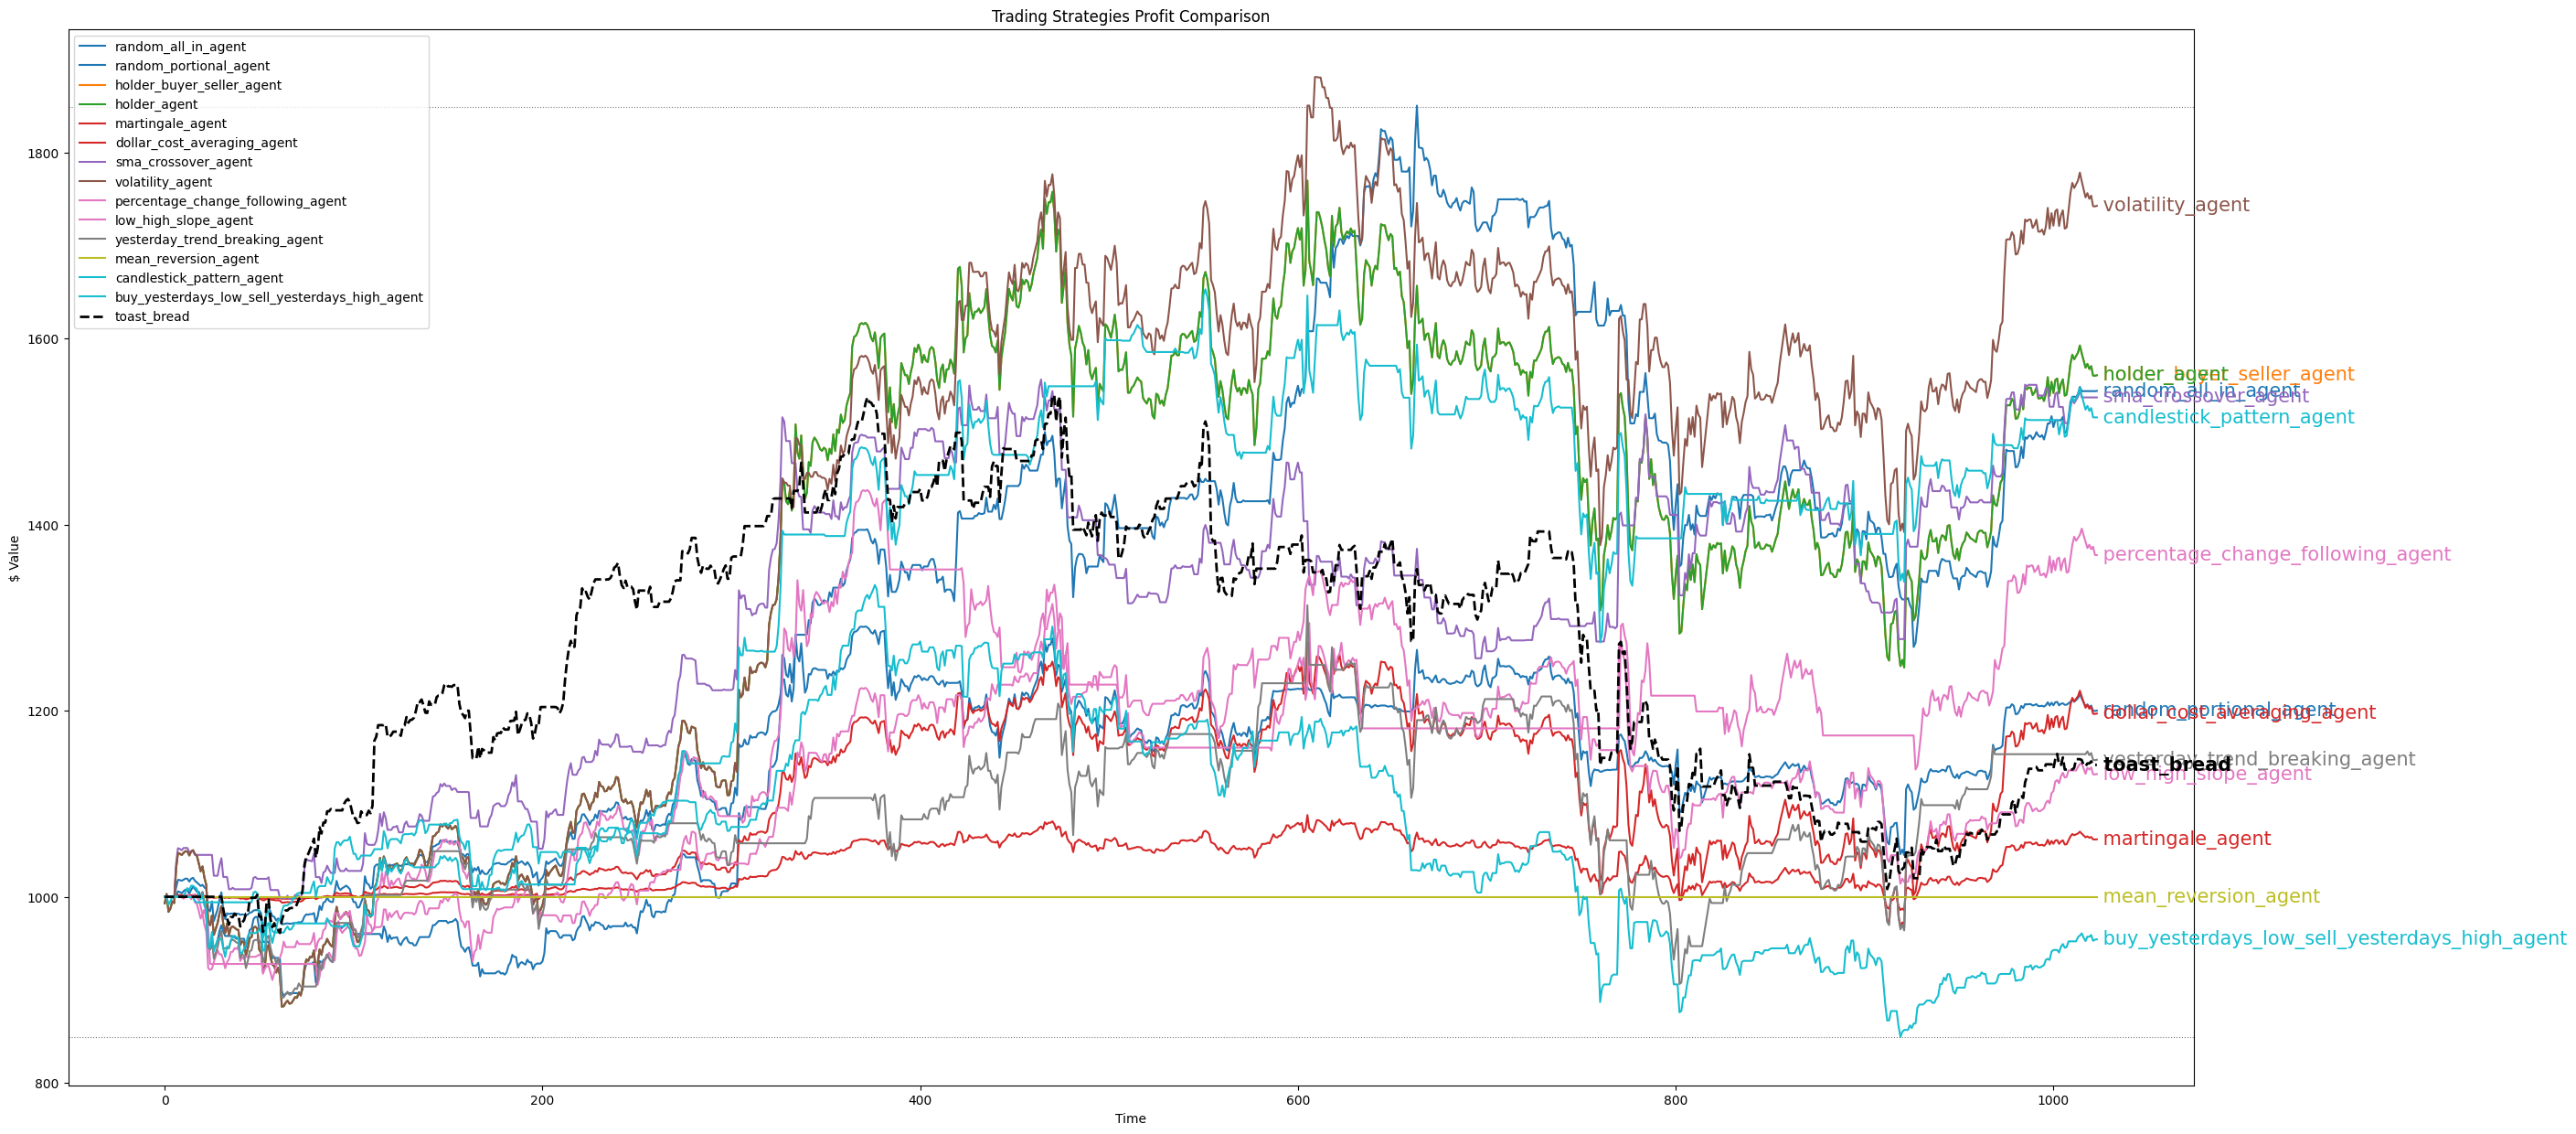

In [ ]:
train_session_dir = "train_sessions_zipped_second_phase/EncoderDecoderLSTM_20250902_192850"
for er in [1,8,24,32]:
    print(er)
    toast_bread_values = profit_inference(train_session_dir, "/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_train.csv", bank_start=args_dict["bank_start"], error_margin=er)
    regular_agent_values = get_trading_agent_values("/home/mericdemirors/Desktop/lecture slides/TUD_lectures/S2/deep_learning_architectures_and_methods/CrossCurrencyPrediction/data/BTC_ETH_BNB_XRP_6h_shared_train.csv", args_dict["output_coins"][0], args_dict["bank_start"])
    compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

## First phase trainings

In [ ]:
args_dict["model_name"] = "TCN"
args = argparse.Namespace(**args_dict)
train_session_dir = train_with_args(args)
create_evaluation_graphs(train_session_dir)
toast_bread_values = profit_inference(train_session_dir, args_dict["profit_inference_csv_path"])
regular_agent_values = get_trading_agent_values(args_dict["profit_inference_csv_path"], args_dict["output_coins"][0], args_dict["bank_start"])
compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

In [ ]:
args_dict["model_name"] = "EncoderDecoderGRU"
args = argparse.Namespace(**args_dict)
train_session_dir = train_with_args(args)
create_evaluation_graphs(train_session_dir)
toast_bread_values = profit_inference(train_session_dir, args_dict["profit_inference_csv_path"])
regular_agent_values = get_trading_agent_values(args_dict["profit_inference_csv_path"], args_dict["output_coins"][0], args_dict["bank_start"])
compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

In [ ]:
args_dict["model_name"] = "EncoderDecoderLSTM"
args = argparse.Namespace(**args_dict)
train_session_dir = train_with_args(args)
create_evaluation_graphs(train_session_dir)
toast_bread_values = profit_inference(train_session_dir, args_dict["profit_inference_csv_path"])
regular_agent_values = get_trading_agent_values(args_dict["profit_inference_csv_path"], args_dict["output_coins"][0], args_dict["bank_start"])
compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

In [ ]:
args_dict["model_name"] = "EncoderDecoderTransformer"
args = argparse.Namespace(**args_dict)
train_session_dir = train_with_args(args)
create_evaluation_graphs(train_session_dir)
toast_bread_values = profit_inference(train_session_dir, args_dict["profit_inference_csv_path"])
regular_agent_values = get_trading_agent_values(args_dict["profit_inference_csv_path"], args_dict["output_coins"][0], args_dict["bank_start"])
compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

In [ ]:
args_dict["model_name"] = "CoinWiseCrossAttentionLSTM"
args = argparse.Namespace(**args_dict)
train_session_dir = train_with_args(args)
create_evaluation_graphs(train_session_dir)
toast_bread_values = profit_inference(train_session_dir, args_dict["profit_inference_csv_path"])
regular_agent_values = get_trading_agent_values(args_dict["profit_inference_csv_path"], args_dict["output_coins"][0], args_dict["bank_start"])
compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

In [ ]:
args_dict["model_name"] = "FeatureWiseCrossAttentionLSTM"
args = argparse.Namespace(**args_dict)
train_session_dir = train_with_args(args)
create_evaluation_graphs(train_session_dir)
toast_bread_values = profit_inference(train_session_dir, args_dict["profit_inference_csv_path"])
regular_agent_values = get_trading_agent_values(args_dict["profit_inference_csv_path"], args_dict["output_coins"][0], args_dict["bank_start"])
compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

## Second phase trainings

In [ ]:
args_dict["model_name"] = "EncoderDecoderGRU"
args = argparse.Namespace(**args_dict)
train_session_dir = train_with_args(args)
create_evaluation_graphs(train_session_dir)
toast_bread_values = profit_inference(train_session_dir, args_dict["profit_inference_csv_path"])
regular_agent_values = get_trading_agent_values(args_dict["profit_inference_csv_path"], args_dict["output_coins"][0], args_dict["bank_start"])
compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

In [ ]:
args_dict["model_name"] = "EncoderDecoderLSTM"
args = argparse.Namespace(**args_dict)
train_session_dir = train_with_args(args)
create_evaluation_graphs(train_session_dir)
toast_bread_values = profit_inference(train_session_dir, args_dict["profit_inference_csv_path"])
regular_agent_values = get_trading_agent_values(args_dict["profit_inference_csv_path"], args_dict["output_coins"][0], args_dict["bank_start"])
compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

In [ ]:
args_dict["dataset_name"] = "IntervalLogReturnTransformLowHighRootCoinDataset"

In [ ]:
args_dict["model_name"] = "EncoderDecoderGRU"
args = argparse.Namespace(**args_dict)
train_session_dir = train_with_args(args)
create_evaluation_graphs(train_session_dir)
toast_bread_values = profit_inference(train_session_dir, args_dict["profit_inference_csv_path"])
regular_agent_values = get_trading_agent_values(args_dict["profit_inference_csv_path"], args_dict["output_coins"][0], args_dict["bank_start"])
compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

In [ ]:
args_dict["model_name"] = "EncoderDecoderLSTM"
args = argparse.Namespace(**args_dict)
train_session_dir = train_with_args(args)
create_evaluation_graphs(train_session_dir)
toast_bread_values = profit_inference(train_session_dir, args_dict["profit_inference_csv_path"])
regular_agent_values = get_trading_agent_values(args_dict["profit_inference_csv_path"], args_dict["output_coins"][0], args_dict["bank_start"])
compare_profits(train_session_dir, regular_agent_values, toast_bread_values, args_dict["input_window"], args_dict["bank_start"])

# Third phase trainigs

## Zipping

In [ ]:
import shutil
shutil.make_archive("train_sessions_zipped", 'zip', "train_sessions")